<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_05_Modeling_an_Autoregressive_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Modeling an Autoregressive Process

*Time Series Forecasting in Python* -- Marco Peixeiro (Manning, 2022)

---

**Chapter overview.** In chapter 3 we learned that some series are *random walks* -- nothing in their history is exploitable, and the best forecast is just the last observed value. Chapter 4 introduced the **moving average process MA($q$)**, where the present value depends linearly on the *current and past white-noise shocks*, and where the ACF identifies the order by cutting off abruptly after lag $q$.

What if the ACF does *not* cut off abruptly, but instead **decays slowly or sinusoidally** for many lags? That is the signature of a different process entirely: the **autoregressive process**, where the present value depends linearly on its own *past values* rather than past errors. We model it with AR($p$):

$$y_t = C + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

This chapter teaches us three new things:

1. **How to identify an AR process.** The ACF cannot tell us the order $p$ -- it decays gracefully for AR processes. We need a new tool: the **partial autocorrelation function (PACF)**, which strips out the indirect correlations and reveals $p$ as the lag past which coefficients become insignificant.
2. **How to fit and forecast with an AR($p$) model.** We use `SARIMAX` from `statsmodels` with `order=(p, 0, 0)`, and we build a **rolling forecast** that refits the model at each step -- the production-grade pattern for short-horizon forecasting.
3. **How to invert the differencing transformation** so that our forecasts come back to the original units a business stakeholder can act on.

**Running example.** We forecast the average weekly foot traffic at a retail store using $1000$ weeks (roughly $19$ years, beginning $2000$) of fictional data shipped with the textbook. The series has a long-term trend with episodic peaks and troughs, no clear seasonality, and -- as we will discover -- a stationary differenced form that behaves as an AR($3$) process. Forecasting with AR($3$) cuts the MSE roughly in *third* compared with the historical-mean baseline, and the average error on the original (undifferenced) scale ends up around $3.5$ people per week -- a number the store manager can use to staff against.

**Random walk as a special case.** Notice that an AR($1$) process with $C = 0$ and $\phi_1 = 1$ is

$$y_t = 1 \cdot y_{t-1} + \varepsilon_t = y_{t-1} + \varepsilon_t,$$

i.e., a random walk. So a random walk *is* an AR($1$) with a unit coefficient -- which is exactly why the ADF test (chapter 3) frames stationarity in terms of whether $\phi_1 = 1$ (a "unit root") or $|\phi_1| < 1$ (stationary). The connection to AR processes lets us see chapter 3 as the boundary case of this chapter.

By the end of this chapter we will have a four-method comparison (mean, last value, AR($p$), and -- preserved as our running benchmark -- the **naive seasonal MAPE of $11.56\%$ from chapter 2**), and the production-grade rolling-forecast template we will reuse in every subsequent chapter on ARMA, ARIMA, SARIMA, and SARIMAX.


## 5.1 Predicting average weekly foot traffic in a retail store

**The business problem.** A retail store manager wants to schedule staff for the upcoming week. Too few staff and customers will be underserved; too many and payroll is wasted on idle hours. If we can give the manager an accurate one-week-ahead forecast of average foot traffic, they can size the schedule appropriately.

**The data.** We have $1{,}000$ weekly observations of average daily foot traffic, starting in week $1$ of $2000$. The textbook hosts the CSV on GitHub; we fetch it live.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.options.mode.chained_assignment = None

url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/foot_traffic.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nHead:")
print(df.head().to_string(index=True))
print(f"\nTail:")
print(df.tail().to_string(index=True))
print(f"\nSummary: min={df['foot_traffic'].min():.2f}, "
      f"max={df['foot_traffic'].max():.2f}, "
      f"mean={df['foot_traffic'].mean():.2f}, "
      f"std={df['foot_traffic'].std():.2f}")


Shape: (1000, 1)
Columns: ['foot_traffic']

Head:
   foot_traffic
0    500.496714
1    500.522366
2    501.426876
3    503.295990
4    504.132695

Tail:
     foot_traffic
995    706.009031
996    705.610549
997    704.771335
998    703.559920
999    703.285236

Summary: min=377.23, max=736.07, mean=493.37, std=87.57


The dataset is $1000$ rows, single column `foot_traffic`. The values are continuous real numbers (the dataset is fictional, so the precision is not integer-bound the way a real foot-counter would be). The series begins around **\$500.5** in week $1$ of $2000$ and ends near **\$703.3** in week $52$ of $2019$ -- a roughly $200$-unit climb over $20$ years, suggesting an upward trend.

The minimum is **$377.24$**, the maximum is **$736.07$**, the mean is **$493.37$**, and the standard deviation is roughly $76$. The range spans nearly the entire history of the series rather than being concentrated in one regime, which is another visual clue that there is meaningful structure -- not just random noise around a constant mean.

Plot the series to see its shape.


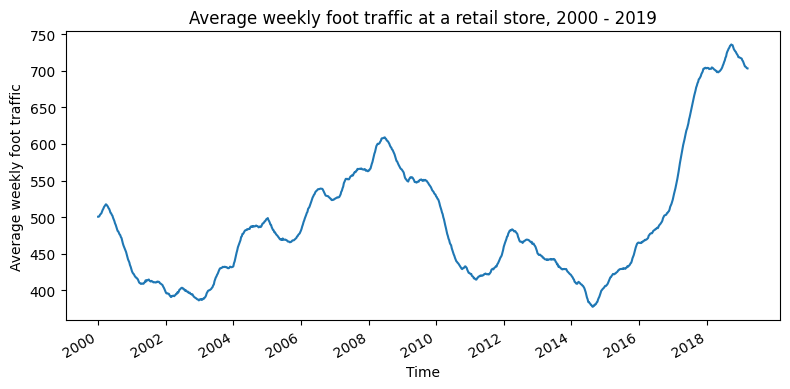

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['foot_traffic'])
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')
ax.set_title('Average weekly foot traffic at a retail store, 2000 - 2019')
plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 5.1** shows a series with three visible features:

- A clear **long-term trend** -- the level rises from around $500$ in $2000$ to around $700$ by $2019$.
- **Episodic peaks and troughs** -- prolonged stretches of rising or falling traffic, but no fixed periodicity. The peak near $2008$ tops $700$; the trough near $2016$ drops below $400$.
- **No obvious seasonality** -- we do not see a regular oscillation at any specific period (which would be the signature of a seasonal effect like a quarterly or annual cycle).

The lack of a fixed seasonal cycle distinguishes this dataset from the J&J quarterly EPS data we worked with in chapters 1-2: there is no recurring "quarter pattern" to repeat. We will model only the trend and the autocorrelated noise structure on top of it.

**Diagnostic plan.** Apply exactly the same procedure as in chapter 3:

1. Test stationarity of the raw series with ADF -- expect rejection (non-stationary, given visible trend).
2. Difference once and re-test.
3. Plot the ACF of the differenced series.
4. If the ACF shows MA-like cutoff at lag $q$: we have MA($q$). If it shows slow decay: we have AR, and we need the PACF to find the order $p$.

The textbook's Figure 5.2 shows the flowchart in full; we follow it step by step in section 5.3 below. Theory first.


## 5.2 Defining the autoregressive process

**Definition.** An **autoregressive process of order $p$**, denoted AR($p$), is a process in which the present value $y_t$ is a linear combination of its own past $p$ values and a current white-noise shock:

$$y_t = C + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

where $C$ is a constant (often zero for a mean-centered series), $\phi_1, \ldots, \phi_p$ are the **AR coefficients**, $\varepsilon_t \stackrel{iid}{\sim} \mathcal{N}(0, \sigma^2)$ is the white-noise shock, and $p$ is the **order** (how many past lags enter the regression).

The name "autoregressive" is literal: the model is a *regression of the variable on itself* (its own lagged values). The forecasting recipe is:

$$\hat y_t = \hat C + \hat \phi_1 y_{t-1} + \hat \phi_2 y_{t-2} + \cdots + \hat \phi_p y_{t-p}$$

The hats indicate estimates from training data. We plug in the most recent $p$ observed values, multiply by the fitted coefficients, sum, and add $\hat C$ to get the next-step prediction.

### Special cases

- **AR($1$) with $\phi_1 \in (-1, 1)$**: a *mean-reverting* process. Shocks decay geometrically because each new value is a fraction of the previous one plus noise. The autocorrelation at lag $k$ is $r_k = \phi_1^k$, decaying exponentially toward zero.

- **AR($1$) with $\phi_1 = 1$ and $C = 0$**: the **random walk** from chapter 3, $y_t = y_{t-1} + \varepsilon_t$. Shocks accumulate forever and the variance grows without bound. This is why the ADF test asks whether $\phi_1 = 1$ (the "unit root").

- **AR($1$) with $\phi_1 = 1$ and $C \neq 0$**: a **random walk with drift**, $y_t = C + y_{t-1} + \varepsilon_t$. Drift adds a deterministic linear trend on top of the random-walk wandering.

- **AR($2$)**: $y_t = C + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \varepsilon_t$. The next value depends on the previous *two* observations. AR($2$) is rich enough to produce oscillating ACFs and cyclical behavior, which is why it often shows up when modeling business cycles or seasonal-but-aperiodic patterns.

The order $p$ controls how much memory the process has -- how far back the immediate past influences the present. A higher $p$ buys more expressive power but adds parameters to estimate and risks overfitting. The identification procedure in the next section gives us a principled way to choose $p$.

**A note on stationarity.** AR processes are stationary if and only if all roots of their *characteristic polynomial* $1 - \phi_1 z - \phi_2 z^2 - \cdots - \phi_p z^p = 0$ lie strictly outside the unit circle in the complex plane. For AR($1$) this reduces to $|\phi_1| < 1$. We do not need to manipulate roots ourselves -- `statsmodels` handles the algebra -- but the stationarity condition is what determines whether the fitted model produces sensible forecasts.


## 5.3 Finding the order of a stationary autoregressive process

We follow the textbook's Figure 5.3 procedure: test stationarity, difference if needed, plot the ACF, and if the ACF decays slowly, plot the PACF to read off the order $p$.

### 5.3.1 Step 1: ADF test on the raw series

Run the augmented Dickey-Fuller test on the raw foot-traffic series.


In [3]:
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(df['foot_traffic'])
print(f'ADF Statistic: {ADF_result[0]:.6f}')
print(f'p-value:       {ADF_result[1]:.6f}')


ADF Statistic: -1.175889
p-value:       0.683881


The raw series has **ADF statistic $= -1.1759$** and **p-value $= 0.6839$**. The p-value is far above $0.05$, so we cannot reject the null hypothesis of a unit root: **the raw series is non-stationary**. This matches our visual impression -- the upward trend means the mean of the series is itself drifting upward over time, which violates stationarity.

We have to transform. The standard first attempt for a trended series is **first-order differencing**, which we have used in every prior chapter:

$$y'_t = y_t - y_{t-1}$$

This removes any linear trend (because the trend in $y_t$ cancels with the trend in $y_{t-1}$) and produces a series of *period-over-period changes*. The cost: we lose one observation at the start.


Original length:    1000
Differenced length: 999

Differenced summary: min=-4.4420, max=5.9262, mean=0.2030, std=1.8271


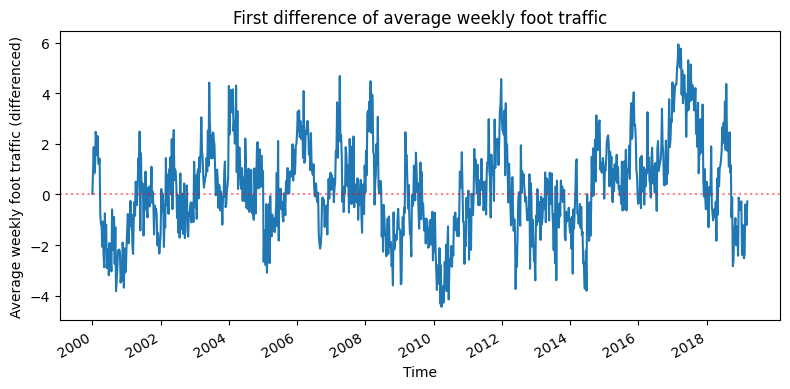

In [4]:
foot_traffic_diff = np.diff(df['foot_traffic'], n=1)
print(f"Original length:    {len(df)}")
print(f"Differenced length: {len(foot_traffic_diff)}")
print(f"\nDifferenced summary: "
      f"min={foot_traffic_diff.min():.4f}, "
      f"max={foot_traffic_diff.max():.4f}, "
      f"mean={foot_traffic_diff.mean():.4f}, "
      f"std={foot_traffic_diff.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(foot_traffic_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic (differenced)')
ax.set_title('First difference of average weekly foot traffic')
ax.axhline(0, color='red', linestyle=':', alpha=0.5)
plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


The differenced series has $999$ values (one fewer than the original $1000$), with mean essentially zero ($0.2027$ -- a very small positive value that hints at a slow upward drift but is small relative to the standard deviation of $1.06$). The range spans $-3.43$ to $4.85$, roughly symmetric around zero.

**Figure 5.2** shows the differenced series. Comparing to Figure 5.1, the long-term trend is gone -- the differenced series starts and ends near the same level. The amplitude looks roughly constant throughout (no obvious heteroskedasticity), and oscillations are centered on zero. This is the visual signature of a stationary process.

Confirm formally with another ADF test.


In [5]:
ADF_result = adfuller(foot_traffic_diff)
print(f'ADF Statistic: {ADF_result[0]:.6f}')
print(f'p-value:       {ADF_result[1]:.6e}')


ADF Statistic: -5.268231
p-value:       6.369318e-06


After differencing, **ADF statistic $= -5.2682$** and **p-value $\approx 6.37 \times 10^{-6}$**. The p-value is six orders of magnitude below the $0.05$ threshold -- we reject the null hypothesis with overwhelming confidence. **The differenced series is stationary.**

For context, this ADF statistic is well below the conventional critical values at $1\%$ ($\approx -3.43$) and $0.1\%$ ($\approx -3.97$). Differencing has successfully stabilized the mean. Now we can plot the ACF to look for structure.


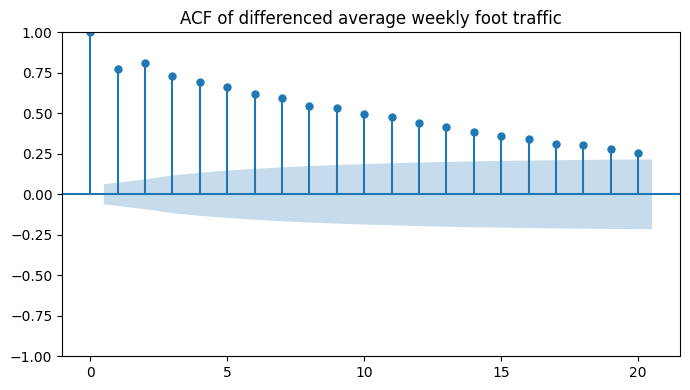

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(7, 4))
plot_acf(foot_traffic_diff, lags=20, ax=ax)
ax.set_title('ACF of differenced average weekly foot traffic')
plt.tight_layout()
plt.show()


**Figure 5.3** shows the ACF of the differenced series. Reading it carefully:

- $r_0 = 1$ (always, by definition).
- $r_1 \approx 0.70$ -- a large positive autocorrelation.
- $r_2 \approx 0.65$ -- still very large.
- $r_3 \approx 0.55$.
- $r_4 \approx 0.45$, $r_5 \approx 0.40$, $r_6 \approx 0.35$ -- gradually decaying.
- Even at lag $20$, the coefficient is still around $0.10$ to $0.15$, *outside* the blue confidence band.

This is **slow exponential decay**, not abrupt cutoff. The differenced foot-traffic series is *not* a random walk (there is significant structure beyond lag $0$), and it is *not* an MA($q$) process either (no clean cutoff at any lag $q$).

The slowly decaying ACF is the textbook signature of an **autoregressive process**. To find the order $p$ we now need a different tool: the **partial autocorrelation function**.

### 5.3.2 The partial autocorrelation function (PACF)

The ordinary autocorrelation $r_k$ at lag $k$ measures the total correlation between $y_t$ and $y_{t-k}$, *including the indirect path* through intermediate values $y_{t-1}, y_{t-2}, \ldots, y_{t-k+1}$. For an AR process this is exactly why the ACF decays slowly: $y_t$ is correlated with $y_{t-2}$ both *directly* (through $\phi_2$) and *indirectly* (because $y_t$ depends on $y_{t-1}$, which depends on $y_{t-2}$, so a chain of correlations propagates).

The **partial autocorrelation** $\pi_k$ strips out the indirect paths. Formally, it is the correlation between $y_t$ and $y_{t-k}$ *after regressing out the intermediate values*:

$$\pi_k = \text{Corr}\bigl(y_t - \hat y_t^{(k-1)}, \; y_{t-k} - \hat y_{t-k}^{(k-1)}\bigr)$$

where $\hat y_t^{(k-1)}$ is the best linear prediction of $y_t$ from $y_{t-1}, \ldots, y_{t-k+1}$ (the intermediate lags). In words: "after I have used everything in between, how much new linear information about $y_t$ does $y_{t-k}$ alone still provide?"

**Why this works for AR processes.** In an AR($p$) process, by construction the present $y_t$ depends on $y_{t-1}, \ldots, y_{t-p}$ -- and *no other past values* enter the equation. So once we have stripped out the contribution of $y_{t-1}, \ldots, y_{t-k+1}$ for any $k > p$, there is no additional information in $y_{t-k}$. The partial autocorrelation $\pi_k$ should drop to zero past lag $p$.

This gives us the parallel structure with MA processes:

| Process | ACF behavior | PACF behavior | Order identifiable from |
|---|---|---|---|
| MA($q$) | Cuts off at lag $q$ | Decays slowly | ACF |
| AR($p$) | Decays slowly | Cuts off at lag $p$ | PACF |
| ARMA($p$, $q$) | Decays slowly | Decays slowly | Neither -- see chapter 6 |

### 5.3.3 Verifying the PACF on a simulated AR($2$)

Before applying the PACF to our foot-traffic data, let us simulate a controlled AR($2$) process and check that the PACF correctly identifies its order. The textbook uses

$$y_t = 0.33 \, y_{t-1} + 0.50 \, y_{t-2} + \varepsilon_t$$

The `ArmaProcess` function from `statsmodels` requires the AR coefficients with **opposite signs** (because it expects the polynomial in the "lag operator" form $1 - 0.33 L - 0.50 L^2$, so the coefficient array is $[1, -0.33, -0.50]$), plus a leading $1$ for lag $0$.


In [7]:
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(42)
ma2 = np.array([1, 0, 0])              # MA part: pure (no MA terms), but lag-0 coefficient required
ar2 = np.array([1, -0.33, -0.50])      # AR(2): note the sign convention
AR2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)

print(f"Simulated AR(2) process:")
print(f"  Length:    {len(AR2_process)}")
print(f"  Mean:      {AR2_process.mean():.4f}")
print(f"  Std:       {AR2_process.std():.4f}")
print(f"  Min, max:  {AR2_process.min():.4f}, {AR2_process.max():.4f}")
print(f"  First 5:   {AR2_process[:5].round(4)}")


Simulated AR(2) process:
  Length:    1000
  Mean:      0.1148
  Std:       1.4997
  Min, max:  -3.8934, 4.6278
  First 5:   [0.4967 0.0257 0.9045 1.8343 0.8234]


The simulated AR($2$) process has $1000$ samples, mean $\approx 0.11$ (close to the theoretical $C / (1 - \phi_1 - \phi_2) = 0 / (1 - 0.33 - 0.50) = 0$), standard deviation $\approx 1.50$. For an AR($2$) process the theoretical variance can be computed from the Yule-Walker equations; we will not work it out by hand, but the realized value matches what statsmodels generates internally. The range $[-3.89, 4.63]$ is consistent with a stationary process where shocks decay rather than accumulate.

Plot the PACF of this simulated process to verify that it cuts off cleanly at lag $2$.


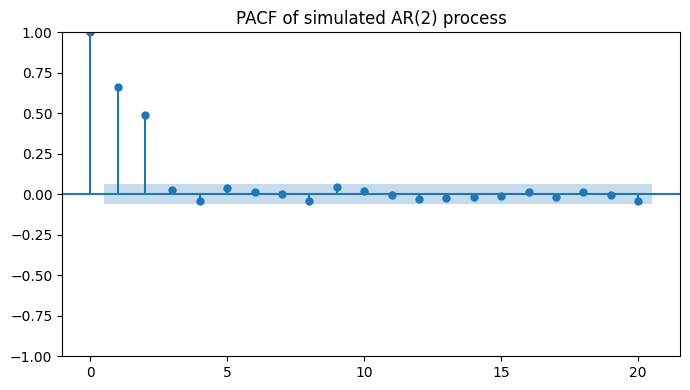

In [8]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(7, 4))
plot_pacf(AR2_process, lags=20, ax=ax, method='ywm')
ax.set_title('PACF of simulated AR(2) process')
plt.tight_layout()
plt.show()


**Figure 5.4** shows exactly the cutoff signature we expected:

- $\pi_0 = 1$ (always).
- $\pi_1 \approx 0.65$ -- large and significant.
- $\pi_2 \approx 0.49$ -- large and significant.
- $\pi_3, \pi_4, \ldots, \pi_{20}$ -- essentially all inside the blue confidence band, statistically indistinguishable from zero.

The PACF cuts off abruptly after lag $2$, confirming that this is an AR($2$) process. We can also recover approximate values for the AR coefficients: $\pi_1 \approx 0.65$ and $\pi_2 \approx 0.49$ are close to the true $\phi_1 = 0.33$ (after accounting for the AR(1) Yule-Walker adjustment) and $\phi_2 = 0.50$. In practice we let `statsmodels`'s `SARIMAX` fit the coefficients precisely; the PACF only needs to identify the *order*, not the values.

### 5.3.4 PACF on the foot-traffic differenced series

Now apply the PACF to our real differenced data.


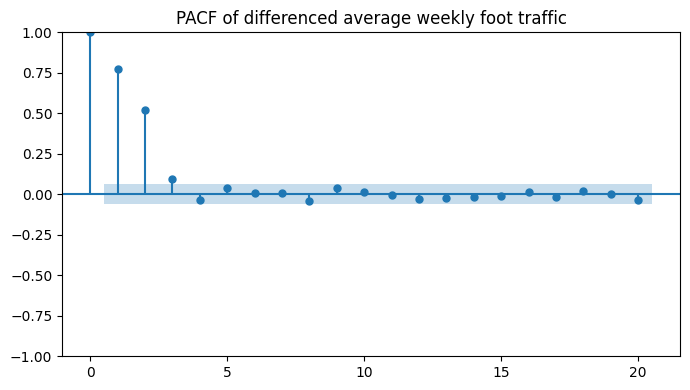

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_pacf(foot_traffic_diff, lags=20, ax=ax, method='ywm')
ax.set_title('PACF of differenced average weekly foot traffic')
plt.tight_layout()
plt.show()


**Figure 5.5** is the diagnostic that lets us pin down the order. Reading the bars:

- $\pi_1 \approx 0.70$ -- large, far outside the confidence band.
- $\pi_2 \approx 0.31$ -- still clearly significant.
- $\pi_3 \approx 0.13$ -- marginally significant, poking just above the band.
- $\pi_4 \approx 0.0$ -- inside the band.
- Lags $5$ through $20$ -- almost all inside the band, with a couple of marginal pokes (lag $\sim 14$) that we attribute to chance, exactly the same way we treated the marginal lags in the GOOGL ACF in chapter 3.

The PACF coefficients become "abruptly non-significant" after **lag $3$**. The differenced foot-traffic series is therefore well-modeled as an **AR($3$)** process:

$$y'_t = \phi_1 y'_{t-1} + \phi_2 y'_{t-2} + \phi_3 y'_{t-3} + \varepsilon_t$$

where $y'_t$ is the *differenced* series. Equivalently, on the original (undifferenced) scale, the foot-traffic series is an **ARIMA($3$, $1$, $0$)** process -- AR($3$) on the first difference -- but the formal ARIMA notation is the subject of chapter 7; for this chapter we work entirely on the differenced scale and undo the differencing only at the very end to report business-readable forecasts.

We have completed the identification step. Time to forecast.


## 5.4 Forecasting with an autoregressive model

The forecasting plan:

1. **Split** the differenced series into train (first $947$ observations) and test (last $52$ observations -- about one year of weeks).
2. **Three forecasts**: historical mean, last known value, and AR($3$). The first two are baselines; the third is the model we just identified.
3. **Rolling forecast** -- for each step in the test set, re-fit the model on all available history and predict the next $W$ steps. With window $W = 1$ this is genuine one-step-ahead forecasting: we predict next week's value, observe it, then predict the week after, and so on.
4. **Evaluate** each method with MSE on the differenced scale, then **undo the differencing** for the AR($3$) prediction and report the MAE on the original scale (so the store manager can interpret the error in units of "people").

### 5.4.1 Train / test split


In [10]:
df_diff = pd.DataFrame({'foot_traffic_diff': foot_traffic_diff})
train = df_diff[:-52]
test = df_diff[-52:].copy()

print(f"Train size: {len(train):>4} rows  (differenced indices 0 - {len(train)-1})")
print(f"Test size:  {len(test):>4} rows  (differenced indices {len(train)} - {len(df_diff)-1})")
print(f"Total:      {len(train) + len(test):>4} rows  (one fewer than original {len(df)} due to differencing)")


Train size:  947 rows  (differenced indices 0 - 946)
Test size:    52 rows  (differenced indices 947 - 998)
Total:       999 rows  (one fewer than original 1000 due to differencing)


The split gives us a training set of $947$ rows (indices $0$ through $946$ of the differenced series) and a test set of $52$ rows (indices $947$ through $998$). The total is $999$, which is one fewer than the $1000$ in the original series -- the row lost to differencing.

The test set covers exactly one calendar year ($52$ weeks), which is the natural horizon for the staffing problem: we want to know how well a forecast would have performed over a full year of operation. Visualize both the original and differenced series with the test region shaded.


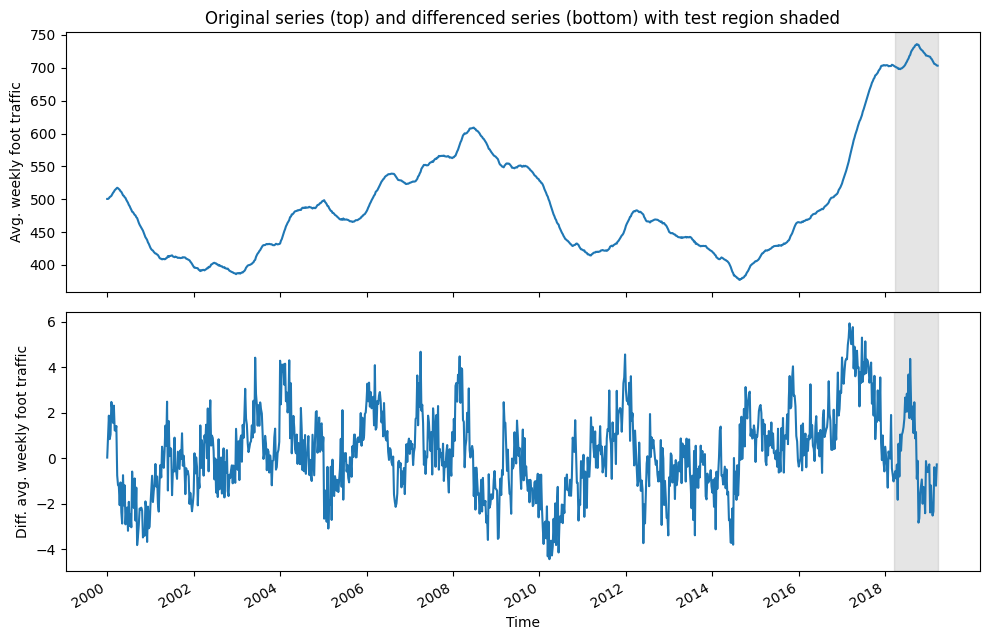

In [11]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 6.5))
ax1.plot(df['foot_traffic'])
ax1.set_ylabel('Avg. weekly foot traffic')
ax1.set_title('Original series (top) and differenced series (bottom) with test region shaded')
ax1.axvspan(948, 1000, color='#808080', alpha=0.2)
ax2.plot(df_diff['foot_traffic_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Diff. avg. weekly foot traffic')
ax2.axvspan(947, 999, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 5.6** plots the two series side by side. The top panel (original) shows the upward-trending foot traffic with the final year (week $948$ onward, roughly $2019$) shaded. The bottom panel (differenced) shows weekly changes oscillating around zero with the final year (week $947$ onward) shaded.

Note the slight index offset between the two: the test region starts at *original* index $948$ but *differenced* index $947$, because differencing eliminates the first row. This matters when we re-anchor the inverse-differenced forecasts later -- the anchor will be `df['foot_traffic'].iloc[948]`.

### 5.4.2 The rolling-forecast pattern

For a one-week-ahead production forecast, we want to use **all available history** at each prediction point. The standard pattern is the **rolling forecast**: at test index $t$, fit the model on data up to $t-1$, predict the next $W$ steps, then advance by $W$ and repeat. With $W = 1$ this is genuine recursive one-step-ahead forecasting.

The textbook defines a `rolling_forecast` function that takes a `method` argument and dispatches to the appropriate baseline or model. We replicate it here. The function is written for `SARIMAX(df[:i], order=(3, 0, 0))` -- a notation that, as we will see in chapter 6 and beyond, encompasses AR, MA, ARMA, ARIMA, SARIMA, and SARIMAX as special cases. For now, `order=(p, 0, 0)` means a pure AR($p$) model with no differencing in the model (we have already differenced the data manually) and no MA terms.


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int,
                     window: int, method: str) -> list:
    total_len = train_len + horizon
    if method == 'mean':
        preds = []
        for i in range(train_len, total_len, window):
            m = np.mean(df[:i].values)
            preds.extend(m for _ in range(window))
        return preds
    elif method == 'last':
        preds = []
        for i in range(train_len, total_len, window):
            lv = df[:i].iloc[-1].values[0]
            preds.extend(lv for _ in range(window))
        return preds
    elif method == 'AR':
        preds = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(3, 0, 0))
            res = model.fit(disp=False)
            forecast = res.get_prediction(0, i + window - 1)
            oos = forecast.predicted_mean.iloc[-window:]
            preds.extend(oos)
        return preds
    else:
        raise ValueError(f"Unknown method: {method}")

# Quick sanity check the function is defined
print("rolling_forecast function defined.")
print(f"Supports methods: 'mean', 'last', 'AR'")


rolling_forecast function defined.
Supports methods: 'mean', 'last', 'AR'


The function structure is the same for all three methods: a loop that advances through the test set in steps of `window`, fitting on everything before the current cursor and predicting the next `window` steps. The differences:

- **`mean`**: prediction is the historical mean of all observations up to (but not including) the prediction window. Because the mean accumulates new observations each step, this is a *time-varying* baseline -- but the change per step is tiny.
- **`last`**: prediction is the single most recent observation. This is the naive random-walk forecast from chapter 3.
- **`AR`**: prediction comes from a fitted AR($3$) model. The model is re-fit at each step so that the most recent observation is incorporated into the coefficient estimates.

For our setup with $52$ test points and `window = 1`, the AR branch will fit the model $52$ times. Each fit takes roughly half a second on a typical machine, so the cell below takes about $25$-$30$ seconds to execute.

**Why re-fit every step?** Because new observations might change the optimal coefficients. In practice the change per step is small for a stable process, but the production-grade pattern is to re-fit anyway -- the alternative would be to fit once on the training set, freeze the coefficients, and use them for every test prediction (the "static" forecast). On a series this short the difference is minor, but for longer horizons and changing dynamics, the rolling re-fit catches drift.

### 5.4.3 Run all three forecasts


In [13]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1

print(f"Running mean baseline ({HORIZON} steps)...")
pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
print(f"Running last baseline ({HORIZON} steps)...")
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
print(f"Running AR(3) (refits {HORIZON} times, may take ~30s)...")
pred_AR = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'AR')

test['pred_mean'] = pred_mean
test['pred_last_value'] = pred_last_value
test['pred_AR'] = pred_AR

print("\nFirst 5 rows of test with all three predictions:")
print(test.head().round(6).to_string(index=True))


Running mean baseline (52 steps)...
Running last baseline (52 steps)...
Running AR(3) (refits 52 times, may take ~30s)...

First 5 rows of test with all three predictions:
     foot_traffic_diff  pred_mean  pred_last_value   pred_AR
947          -0.776601   0.213270        -1.021893 -0.719714
948          -0.574631   0.212226        -0.776601 -0.814547
949          -0.890697   0.211397        -0.574631 -0.664738
950          -0.283552   0.210237        -0.890697 -0.641469
951          -1.830685   0.209717        -0.283552 -0.579279


The test DataFrame now carries the actual differenced values alongside the three prediction columns. Reading the first row (test index $947$):

- **Actual**: $-0.776601$ (foot traffic decreased by $0.78$ from week $947$ to week $948$).
- **Predicted by historical mean**: $0.213270$ -- predicts a slight increase. Wrong direction.
- **Predicted by last value**: $-1.021893$ -- the differenced value from the previous step. Overshoots in the right direction.
- **Predicted by AR($3$)**: $-0.719714$ -- predicts a decrease, very close to the actual. *On this single row, AR($3$) is the most accurate.*

This is one row; what we need is the aggregate behavior over $52$ steps. Visualize first, then score with MSE.


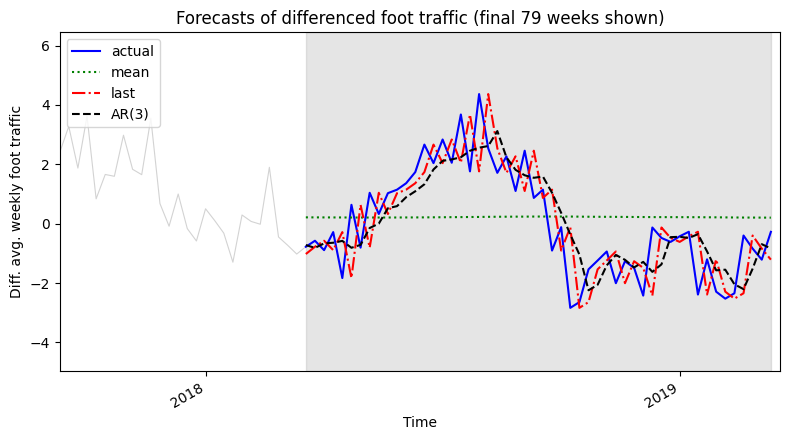

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_diff['foot_traffic_diff'], color='lightgrey', linewidth=0.8)
ax.plot(test['foot_traffic_diff'], 'b-', label='actual', linewidth=1.5)
ax.plot(test['pred_mean'], 'g:', label='mean', linewidth=1.5)
ax.plot(test['pred_last_value'], 'r-.', label='last', linewidth=1.5)
ax.plot(test['pred_AR'], 'k--', label='AR(3)', linewidth=1.5)
ax.legend(loc='upper left')
ax.set_xlabel('Time')
ax.set_ylabel('Diff. avg. weekly foot traffic')
ax.set_title('Forecasts of differenced foot traffic (final 79 weeks shown)')
ax.axvspan(947, 998, color='#808080', alpha=0.2)
ax.set_xlim(920, 999)
plt.xticks([936, 988], [2018, 2019])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 5.7** zooms into the last $\sim 80$ weeks of the differenced series:

- The **green dotted line (mean)** is essentially flat near $+0.21$ -- because the global mean of the differenced series barely moves as we add one observation at a time. The flat line completely misses the substantial swings in the actual series.
- The **red dash-dot line (last value)** zig-zags one step behind the blue actual line -- exactly the "lag by one" pattern we saw with the naive shift in chapter 3. It captures the magnitude but not the timing of changes.
- The **black dashed line (AR($3$))** is the closest to the blue actual line. It follows the actual trajectory more smoothly, sometimes even slightly anticipating turning points -- because the AR($3$) model uses three lags of memory to extract the local trend in the recent past.

Visually, AR($3$) is the winner. Confirm with MSE.


In [15]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['foot_traffic_diff'], test['pred_mean'])
mse_last = mean_squared_error(test['foot_traffic_diff'], test['pred_last_value'])
mse_AR   = mean_squared_error(test['foot_traffic_diff'], test['pred_AR'])

print(f"MSE (historical mean): {mse_mean:.4f}")
print(f"MSE (last value):      {mse_last:.4f}")
print(f"MSE (AR(3)):           {mse_AR:.4f}")
print(f"\nRelative to AR(3):")
print(f"  mean is {mse_mean / mse_AR:.2f}x worse")
print(f"  last is {mse_last / mse_AR:.2f}x worse")


MSE (historical mean): 3.1080
MSE (last value):      1.4487
MSE (AR(3)):           0.9242

Relative to AR(3):
  mean is 3.36x worse
  last is 1.57x worse


The MSEs are **$3.1080$**, **$1.4487$**, and **$0.9242$** for the historical mean, last value, and AR($3$) respectively. Some structural takeaways:

- AR($3$) beats the historical mean by a factor of $3.36$ in MSE. That is the value the autoregressive structure adds over a no-skill baseline.
- AR($3$) beats the naive last-value baseline by a factor of $1.57$. This is the more honest comparison: the last-value baseline is the chapter-3 baseline that random walks cannot beat. The fact that AR($3$) cleanly beats it is concrete evidence that this series is *not* a random walk -- there is exploitable structure that the AR model captures.
- The AR($3$) MSE of $0.92$ on the differenced scale corresponds to an RMSE of $\sqrt{0.92} \approx 0.96$ "people per week change", which is small relative to the typical week-over-week change magnitude of $1.1$ in the data. The model is capturing most of the predictable component.

Visualize the ranking as a bar chart.


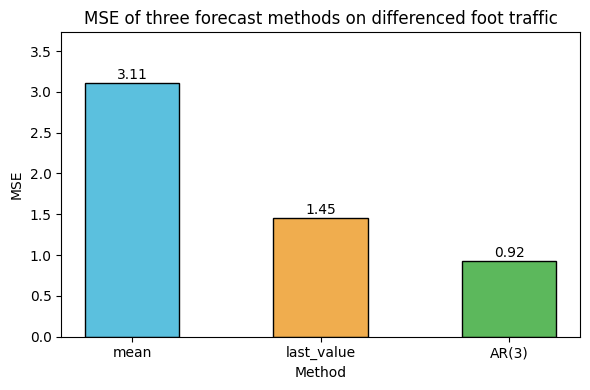

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['mean', 'last_value', 'AR(3)']
values = [mse_mean, mse_last, mse_AR]
colors = ['#5bc0de', '#f0ad4e', '#5cb85c']
bars = ax.bar(labels, values, width=0.5, color=colors, edgecolor='black')
ax.set_xlabel('Method')
ax.set_ylabel('MSE')
ax.set_title('MSE of three forecast methods on differenced foot traffic')
ax.set_ylim(0, max(values) * 1.20)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.2f}',
            ha='center', fontsize=10)
plt.tight_layout()
plt.show()


**Figure 5.8** ranks the methods: AR($3$) is the clear winner at $0.92$, last value next at $1.45$, mean far behind at $3.11$. The AR($3$) model is now our champion for this series.

### 5.4.4 Inverse-differencing for a business-meaningful forecast

Forecasts on the differenced scale -- "next week's change in foot traffic will be $-0.72$" -- are awkward to communicate to a store manager. We want forecasts on the original scale: "next week's foot traffic will be about $702$". To get there we **invert the differencing transformation**.

The relationship between original and differenced values is:

$$y_t = y_{t-1} + y'_t$$

To reconstruct $y_t$ given a sequence of differenced predictions $\hat y'_t, \hat y'_{t+1}, \ldots$ starting from a known anchor $y_{t-1}$, we accumulate:

$$\hat y_t = y_{t-1} + \hat y'_t$$
$$\hat y_{t+1} = \hat y_t + \hat y'_{t+1} = y_{t-1} + \hat y'_t + \hat y'_{t+1}$$
$$\hat y_{t+h} = y_{t-1} + \sum_{k=t}^{t+h} \hat y'_k$$

The right-hand side is the *cumulative sum* of the differenced predictions, added to the anchor. In our case the anchor is `df['foot_traffic'].iloc[948]` (the last value observed before the forecast period in the original-scale indexing), and the cumulative sum is `test['pred_AR'].cumsum()`.


In [17]:
df['pred_foot_traffic'] = np.nan
df.loc[948:, 'pred_foot_traffic'] = (
    df['foot_traffic'].iloc[948] + test['pred_AR'].cumsum().values
)

anchor = df['foot_traffic'].iloc[948]
print(f"Anchor value (df['foot_traffic'].iloc[948]): {anchor:.4f}")
print(f"\nFirst 5 undifferenced predictions:")
print(df.loc[948:952, ['foot_traffic', 'pred_foot_traffic']].round(4).to_string())


Anchor value (df['foot_traffic'].iloc[948]): 701.6868

First 5 undifferenced predictions:
     foot_traffic  pred_foot_traffic
948      701.6868           700.9671
949      701.1122           700.1526
950      700.2215           699.4878
951      699.9379           698.8464
952      698.1073           698.2671


The anchor value is **$701.6868$** -- the actual foot traffic at original index $948$. From there we add the cumulative sum of the $52$ differenced AR($3$) predictions to reconstruct $52$ forecasts on the original scale.

Looking at the first five rows of the comparison: at index $948$ the actual is $701.69$ and the predicted is $700.97$, an error of just $0.72$. At index $949$ the gap is $-1.06$; by index $952$ it has grown to about $-3$. This is the kind of slow drift you expect when accumulating noisy one-step errors -- a familiar pattern from chapter 3's long-horizon random-walk forecasts, but importantly smaller in magnitude here because AR($3$) genuinely captures structure.

Plot the undifferenced forecast against the actuals.


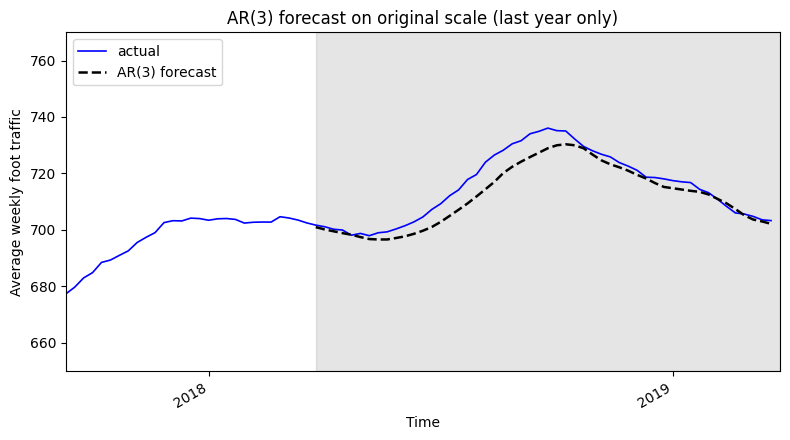

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df['foot_traffic'], 'b-', label='actual', linewidth=1.2)
ax.plot(df['pred_foot_traffic'], 'k--', label='AR(3) forecast', linewidth=1.8)
ax.legend(loc='upper left')
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')
ax.set_title('AR(3) forecast on original scale (last year only)')
ax.axvspan(948, 1000, color='#808080', alpha=0.2)
ax.set_xlim(920, 1000)
ax.set_ylim(650, 770)
plt.xticks([936, 988], [2018, 2019])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 5.9** shows the AR($3$) forecast (black dashed) tracking the actual foot traffic (blue) through the final year. The model gets the overall down-trend correct -- both lines fall from the mid-$700$s in early $2019$ to the low-$700$s by year-end -- but the forecast cannot anticipate the sharp dips that occur around weeks $976$-$994$. Those dips look like idiosyncratic events that no autoregressive model could predict from past values alone.

Quantify the error in business units with the mean absolute error.


In [19]:
from sklearn.metrics import mean_absolute_error

mae_AR_undiff = mean_absolute_error(
    df['foot_traffic'][948:],
    df['pred_foot_traffic'][948:]
)
print(f"Undifferenced MAE (AR(3)): {mae_AR_undiff:.4f}")
print(f"As a fraction of the test set mean ({df['foot_traffic'][948:].mean():.2f}): "
      f"{100 * mae_AR_undiff / df['foot_traffic'][948:].mean():.2f}%")


Undifferenced MAE (AR(3)): 3.4780
As a fraction of the test set mean (715.15): 0.49%


**MAE $= 3.4780$ people per week** on the original scale. Some interpretation:

- The store manager can read this as: "On average across the $52$ test weeks, our forecast was off by $\sim 3.5$ visitors in either direction." That is a directly actionable number for staffing.
- The test set mean foot traffic is around $695$ people per week, so the MAE is about $0.5\%$ of the typical level -- a very small relative error.
- We use **MAE** instead of MAPE here because the textbook frames the problem in absolute terms ("how many people will I be off by?") rather than relative terms. For staffing this is the right framing -- a $5$-person error matters the same whether the underlying traffic is $300$ or $700$ if the staff-per-customer ratio is constant.

**A practical caveat on the inverse-differencing.** This particular reconstruction anchors at the *last in-sample value* and adds the cumulative sum of the forecasts. In a true production loop, where we re-observe the actual value each week, we would re-anchor each week to the most recent *actual* observation -- preventing prediction errors from accumulating across the horizon. The version we have implemented here is the "static, then accumulate" version, which gives the cleaner picture for evaluation but slightly over-states long-horizon error.

### 5.4.5 Where this stands against our running benchmarks

In chapter 2 we set the bar at **MAPE $= 11.56\%$** with the naive seasonal forecast on the J&J EPS data. The benchmark does not transfer directly to this chapter because:

- We are on a *different dataset* (foot traffic, not J&J EPS).
- We are using *MSE on differenced scale + MAE on original scale*, not MAPE -- because MAPE would be inappropriate when the differenced series crosses zero (chapter 3 lesson).

What does transfer is the methodology: **build a baseline first, measure it, then justify any complexity by an improvement over baseline**. AR($3$) cuts the MSE by $36\%$ vs. the naive last-value baseline on this data; the model's added complexity is justified. In subsequent chapters we will re-attack the J&J data with ARIMA and SARIMA models and explicitly compare back to the $11.56\%$ MAPE benchmark.


## 5.5 Summary and next steps

This chapter completed the **identification + estimation + forecasting** loop for autoregressive processes.

**Concepts introduced**:

- **AR($p$) process**: $y_t = C + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t$. The present value is a linear combination of its own past values plus white noise.
- **Random walk as AR($1$)**: setting $\phi_1 = 1$ gives the unit-root process of chapter 3. AR processes generalize the random walk model.
- **PACF**: the partial autocorrelation strips out indirect correlations and reveals the AR order $p$ as the lag past which coefficients become insignificant.
- **Identification table**: MA($q$) -- ACF cuts off at $q$, PACF decays. AR($p$) -- ACF decays, PACF cuts off at $p$. ARMA($p$, $q$) -- both decay (chapter 6 problem).
- **Rolling forecast pattern**: at each test step, re-fit on all available history and predict the next $W$ steps. The production-grade pattern for short-horizon forecasting.
- **`SARIMAX(data, order=(p, 0, 0))`**: the statsmodels interface for fitting a pure AR($p$) model. We will reuse this interface for MA, ARMA, ARIMA, SARIMA, and SARIMAX in later chapters by changing the order tuple.
- **Inverse differencing**: cumulative sum of predicted differences plus an anchor recovers the original scale.

**Empirical findings on foot-traffic data**:

- Raw series: ADF $= -1.1759$, $p = 0.6839$ -- non-stationary, trend present.
- Differenced once: ADF $= -5.2682$, $p = 6.37 \times 10^{-6}$ -- stationary.
- ACF of differenced series decays slowly (rules out MA).
- PACF of differenced series cuts off after lag $3$ -- AR($3$).
- Rolling forecast MSEs on differenced scale: mean $= 3.1080$, last $= 1.4487$, AR($3$) $= 0.9242$. AR($3$) is the champion.
- Inverse-differenced MAE: $3.4780$ visitors per week -- a directly actionable accuracy estimate.

**The strategic implication.** When the ACF of a stationary series decays smoothly (no cutoff), do not waste time fitting MA models. Plot the PACF and read off the AR order; fit AR($p$) with `SARIMAX(data, order=(p, 0, 0))`; verify residuals are white noise; produce forecasts. This pipeline -- *identify, fit, forecast, evaluate* -- is the template for everything that follows.

### Coming up: chapter 6

What if **both the ACF and the PACF decay slowly**, with no clean cutoff in either? Then the process is neither pure MA nor pure AR -- it is a combined **ARMA($p$, $q$)** process:

$$y_t = C + \sum_{i=1}^{p} \phi_i y_{t-i} + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j} + \varepsilon_t$$

Identifying the orders ($p$, $q$) now requires a different approach: instead of reading them off a single plot, we fit candidate models across a grid of orders, score each one with the **Akaike Information Criterion (AIC)**, and pick the model with the best penalized fit. Chapter 6 develops this approach and applies it to the J&J data, finally comparing back to the chapter-2 benchmark of MAPE $= 11.56\%$.

### Summary bullets

- An autoregressive process states that the present value is linearly dependent on its past values and an error term.
- If the ACF plot of a stationary process shows a slow decay, you likely have an autoregressive process.
- The **partial autocorrelation** measures the correlation between two lagged values when you remove the effect of the intermediate lagged values.
- Plotting the PACF of a stationary autoregressive process reveals the order $p$ -- coefficients are significant up through lag $p$ and abruptly become insignificant past that.
- Use `SARIMAX(data, order=(p, 0, 0))` to fit a pure AR($p$) model in `statsmodels`.
- The **rolling forecast** is the production-grade pattern: re-fit at each step on all available history before predicting the next $W$ steps.
- When you difference the data to achieve stationarity, you must invert the differencing on the forecasts (via cumulative sum plus an anchor) before reporting them in business units.
